# Comments

In [153]:
import pandas as pd
import json
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [154]:
comments_raw = []
with open('../data/raw/comments.json') as f:
    comments_raw = json.loads(f.read())

comments_df = pd.DataFrame(comments_raw)
comments_df = comments_df[comments_df['error'] != 'no_items']
comments_df = comments_df.dropna(subset=['text'])
comments_df.head(3)

,inputUrl,error,errorDescription,facebookUrl,commentUrl,commentId,id,feedbackId,date,text,...,postTitle,groupTitle,profileUrl,attachments,commentsCount,comments,pageAdLibrary,replyToCommentId,parentComment,parentReply
3,https://www.facebook.com/groups/98029876786537...,NaN,NaN,https://www.facebook.com/groups/98029876786537...,https://www.facebook.com/groups/98029876786537...,1045207444707837,Y29tbWVudDoxMDQ0OTYxMDk4MDY1ODA1XzEwNDUyMDc0ND...,ZmVlZGJhY2s6MTA0NDk2MTA5ODA2NTgwNV8xMDQ1MjA3ND...,2026-07-20T17:53:24.000Z,Depende po sa klase at complexity ng game. Kun...,...,"hello, may I ask if it is possible po bang mak...",App Builders PH 🇵🇭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.facebook.com/groups/98029876786537...,NaN,NaN,https://www.facebook.com/groups/98029876786537...,https://www.facebook.com/groups/98029876786537...,1045169808044934,Y29tbWVudDoxMDQ0OTYxMDk4MDY1ODA1XzEwNDUxNjk4MD...,ZmVlZGJhY2s6MTA0NDk2MTA5ODA2NTgwNV8xMDQ1MTY5OD...,2026-07-20T16:54:28.000Z,masmaigi po sigurong ide with agentic task nal...,...,"hello, may I ask if it is possible po bang mak...",App Builders PH 🇵🇭,https://www.facebook.com/LunaRenzoX,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,https://www.facebook.com/groups/98029876786537...,NaN,NaN,https://www.facebook.com/groups/98029876786537...,https://www.facebook.com/groups/98029876786537...,1045448131350435,Y29tbWVudDoxMDQ0OTYxMDk4MDY1ODA1XzEwNDU0NDgxMz...,ZmVlZGJhY2s6MTA0NDk2MTA5ODA2NTgwNV8xMDQ1NDQ4MT...,2026-07-21T01:43:59.000Z,"Based on my Experience, try mo muna bro magcon...",...,"hello, may I ask if it is possible po bang mak...",App Builders PH 🇵🇭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
comments_df.info()

<class 'pandas.DataFrame'>
Index: 7666 entries, 3 to 8264
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   inputUrl          7666 non-null   str    
 1   error             0 non-null      str    
 2   errorDescription  0 non-null      str    
 3   facebookUrl       7666 non-null   str    
 4   commentUrl        7666 non-null   str    
 5   commentId         7666 non-null   str    
 6   id                7666 non-null   str    
 7   feedbackId        7666 non-null   str    
 8   date              7666 non-null   str    
 9   text              7666 non-null   str    
 10  author            7666 non-null   object 
 11  profilePicture    7666 non-null   str    
 12  profileId         7666 non-null   str    
 13  profileName       7666 non-null   str    
 14  likesCount        7666 non-null   str    
 15  threadingDepth    7666 non-null   float64
 16  facebookId        7666 non-null   str    
 17  postTitle  

In [156]:
comments_df['date'] = pd.to_datetime(comments_df['date'])
comments_df.info()

<class 'pandas.DataFrame'>
Index: 7666 entries, 3 to 8264
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   inputUrl          7666 non-null   str                
 1   error             0 non-null      str                
 2   errorDescription  0 non-null      str                
 3   facebookUrl       7666 non-null   str                
 4   commentUrl        7666 non-null   str                
 5   commentId         7666 non-null   str                
 6   id                7666 non-null   str                
 7   feedbackId        7666 non-null   str                
 8   date              7666 non-null   datetime64[us, UTC]
 9   text              7666 non-null   str                
 10  author            7666 non-null   object             
 11  profilePicture    7666 non-null   str                
 12  profileId         7666 non-null   str                
 13  profileName       7

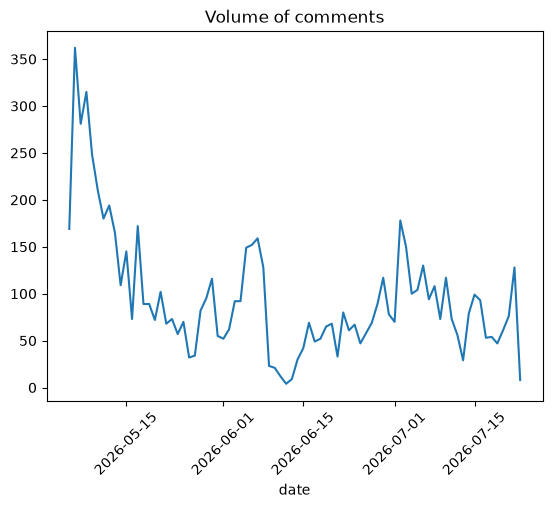

In [157]:
comments_df['date'].dt.date.value_counts().sort_index().plot(kind='line', rot=45)
plt.title('Volume of comments')
plt.show()

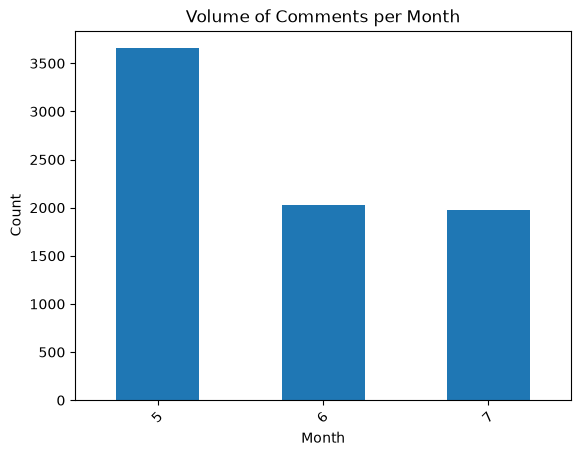

In [158]:
comments_df['date'].dt.month.value_counts().plot(kind='bar', rot=45)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Volume of Comments per Month')
plt.show()

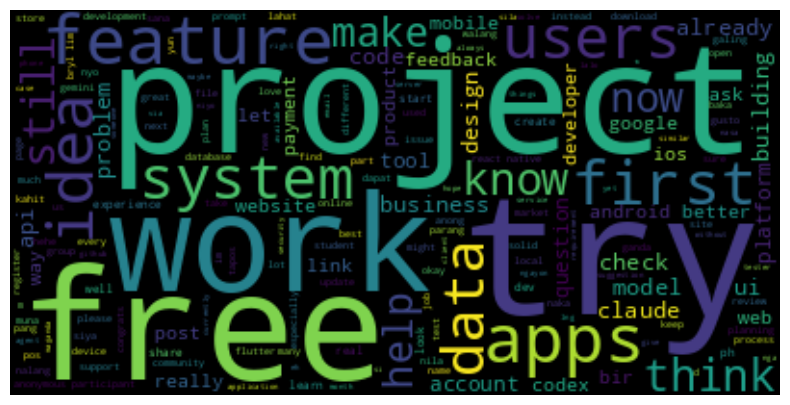

In [159]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS) | { 
    'na', 'ng', 'sa', 
    'ang', 'may', 'app', 
    'built', 'build', 'po', 
    'yung', 's', 'https',
    'mga', 'ai', 'ko', 'lang',
    'one', 'ako', 'mo', 'yan', 
    'kasi', 'sir', 'din', 'pero', 
    'ka', 'pa', 'will', 'use', 'need', 'user',
    'mag', 'thank', 'thanks', 'ba', 'naman', 'using',
    'bro', 'pag', 'nice', 'para', 'pwede', 'ung', 'u',
    'ma', 'di', 'nag', 'hindi', 'hahaha', 'yes', 'hello',
    'etc', 'sya', 'ito', 'hi', 'mas', 'kaya', 'ano', 'rin',
    'dito', 'haha', 'actually', 'go', 'talaga', 'see', 'based',
    'even', 'kayo', 'io', 'want', 'good', 'thing', 'add', 'meron',
    'gamit', 'day', 'kung', 'people', 'something', 'time', 'wala',
    'boss',
}
wc = WordCloud(stopwords=stopwords).generate(' '.join(comments_df['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Comments in May

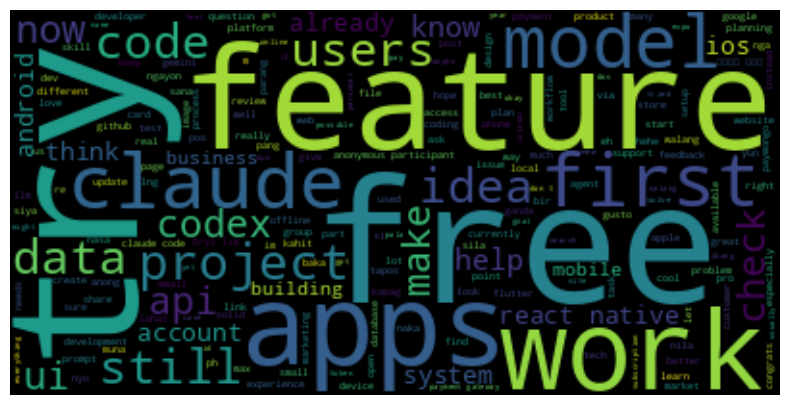

In [160]:
comments_may_df = comments_df[(comments_df['date'] >= '2026-05-01') & (comments_df['date'] < '2026-06-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(comments_may_df['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Comments in June

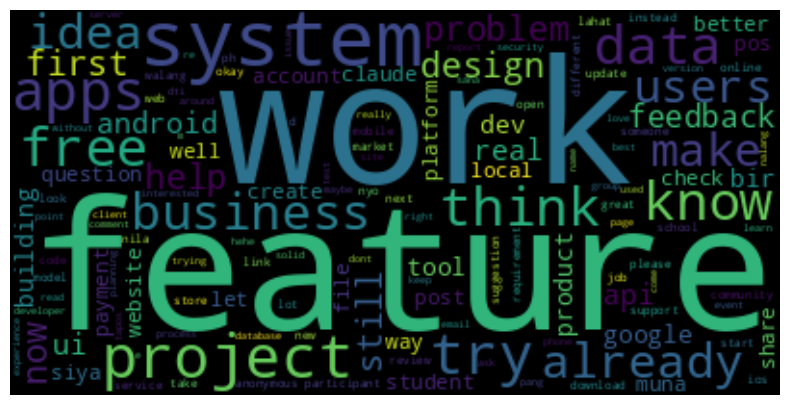

In [161]:
comments_june_df = comments_df[(comments_df['date'] >= '2026-06-01') & (comments_df['date'] < '2026-07-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(comments_june_df['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

# Comments in July

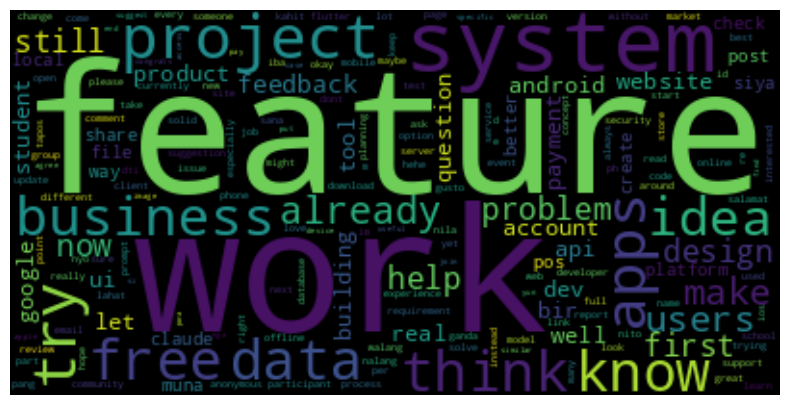

In [162]:
comments_july_df = comments_df[(comments_df['date'] >= '2026-06-01') & (comments_df['date'] < '2026-07-01')]
wc = WordCloud(stopwords=stopwords).generate(' '.join(comments_july_df['text']).lower())
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()